<a href="https://colab.research.google.com/github/apopuri584/lean_mass_predictor/blob/main/nhanes_checkin4_revised_rf_tuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Setup & Data Loading

In [ ]:


# @title
import io
import requests
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Libraries loaded.')


Libraries loaded.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Download NHANES 2017-2018 components directly from CDC (no upload needed)
# ═══════════════════════════════════════════════════════════════════════════
#   DEMO_J   - Demographics            (SEQN, RIAGENDR sex, RIDAGEYR age)
#   BMX_J    - Body Measures           (BMXWT weight kg, BMXHT height cm)
#   DR1TOT_J - Dietary Interview Day 1 (DR1TPROT protein g, DR1TKCAL kcal)
#   PAQ_J    - Physical Activity Q'aire(PAQ650 vigorous activity, PAD680 sedentary min)
#   DXX_J    - Whole-Body DXA          (DXDTOLE total lean mass excl. BMC, g)
#
# Target variable for this project, used everywhere: TOTAL LEAN MASS (kg).

NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/'

NHANES_FILES = {
    'DEMO':   'DEMO_J.xpt',
    'BMX':    'BMX_J.xpt',
    'DR1TOT': 'DR1TOT_J.xpt',
    'PAQ':    'PAQ_J.xpt',
    'DXX':    'DXX_J.xpt',
}

def load_xpt(filename):
    url = NHANES_BASE + filename
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return pd.read_sas(io.BytesIO(resp.content), format='xport')

print('Downloading NHANES 2017-2018 component files from CDC ...')
nhanes_tables = {}
try:
    for key, fname in NHANES_FILES.items():
        print(f'  Fetching {fname} ...')
        nhanes_tables[key] = load_xpt(fname)
        print(f'    -> {nhanes_tables[key].shape[0]} rows, {nhanes_tables[key].shape[1]} columns')
except Exception as exc:
    raise RuntimeError(
        'Could not download NHANES data from CDC. Check that this runtime has '
        'internet access (Colab does by default). Original error: ' + str(exc)
    )

demo = nhanes_tables['DEMO'][['SEQN', 'RIAGENDR', 'RIDAGEYR']]
bmx  = nhanes_tables['BMX'][['SEQN', 'BMXWT', 'BMXHT']]
diet = nhanes_tables['DR1TOT'][['SEQN', 'DR1TPROT', 'DR1TKCAL']]
paq  = nhanes_tables['PAQ'][['SEQN', 'PAQ650', 'PAD680']]
dxx  = nhanes_tables['DXX'][['SEQN', 'DXDTOLE']]   # Total Lean excl BMC (g)

# ── Merge all components on SEQN (respondent sequence number) ───────────────
raw_df = (demo.merge(bmx,  on='SEQN', how='inner')
               .merge(diet, on='SEQN', how='inner')
               .merge(paq,  on='SEQN', how='inner')
               .merge(dxx,  on='SEQN', how='inner'))

# ── Restrict to young adults aged 20-39 (this project's target population) ──
raw_df = raw_df[(raw_df['RIDAGEYR'] >= 20) & (raw_df['RIDAGEYR'] <= 39)].copy()

# ── Target variable: Total Lean Mass (kg) ────────────────────────────────────
# DXDTOLE = "Total Lean excl BMC" in grams (DXX_J codebook) -> convert to kg.
# This is TOTAL lean mass, not appendicular lean mass, and it is the only
# lean-mass definition used anywhere in this notebook.
raw_df['target_lean_mass_kg'] = raw_df['DXDTOLE'] / 1000.0
raw_df = raw_df.drop(columns=['DXDTOLE']).reset_index(drop=True)

print()
print(f'Merged + age-filtered (20-39 yrs) sample: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns')
display(raw_df.head())
]'
p[]\78op[]\789+p;[9-9ool;/
'+699366666*-6o'
'+
01+8

  Fetching DEMO_J.xpt ...
    -> 9254 rows, 46 columns
  Fetching BMX_J.xpt ...
    -> 8704 rows, 21 columns
  Fetching DR1TOT_J.xpt ...
    -> 8704 rows, 168 columns
  Fetching PAQ_J.xpt ...
    -> 5856 rows, 17 columns
  Fetching DXX_J.xpt ...
    -> 5114 rows, 93 columns

Merged + age-filtered (20-39 yrs) sample: 1589 rows, 10 columns


,SEQN,RIAGENDR,RIDAGEYR,BMXWT,BMXHT,DR1TPROT,DR1TKCAL,PAQ650,PAD680,target_lean_mass_kg
0,93717.0,1.0,22.0,74.4,174.1,97.12,3151.0,2.0,300.0,57.5789
1,93731.0,1.0,20.0,89.2,179.9,71.81,2266.0,1.0,360.0,59.1333
2,93738.0,1.0,26.0,97.7,170.2,116.36,857.0,1.0,180.0,70.9429
3,93746.0,2.0,25.0,62.1,158.4,80.67,1544.0,2.0,540.0,40.4421
4,93755.0,2.0,26.0,93.8,178.5,100.01,2693.0,1.0,480.0,51.2344


---
## Data Cleaning & Preprocessing

In [ ]:
df = raw_df.copy()
n_start = len(df)

# ── PAD680 (sedentary minutes/day): remove BOTH special codes ───────────────
# 7777 = Refused, 9999 = Don't know. (Previous version only removed 9999.)
n_before = len(df)
df = df[~df['PAD680'].isin([7777, 9999])].copy()
n_removed_pad680 = n_before - len(df)
print(f"Removed {n_removed_pad680} rows with PAD680 in {{7777, 9999}} (Refused / Don't know)")

# ── PAQ650 (vigorous recreational activity): recode to binary ───────────────
# NHANES coding: 1=Yes, 2=No, 7=Refused, 9=Don't know.
# 7/9 map to NaN here and are removed in the dropna step below.
n_removed_paq650 = int(df['PAQ650'].isin([7, 9]).sum())
df['PAQ650_binary'] = df['PAQ650'].map({1.0: 1, 2.0: 0})
print(f"Flagged {n_removed_paq650} rows with PAQ650 in {{7, 9}} (Refused / Don't know) for removal")

# ── Compute BMI and protein per kg body weight ───────────────────────────────
df['BMI'] = df['BMXWT'] / ((df['BMXHT'] / 100) ** 2)
df['protein_g_per_kg'] = df['DR1TPROT'] / df['BMXWT']

# ── Drop rows missing any modelling variable ─────────────────────────────────
model_cols = ['RIAGENDR', 'RIDAGEYR', 'BMXHT', 'BMXWT', 'BMI',
              'DR1TPROT', 'protein_g_per_kg', 'DR1TKCAL',
              'PAD680', 'PAQ650_binary', 'target_lean_mass_kg']
n_before_dropna = len(df)
df = df.dropna(subset=model_cols).reset_index(drop=True)
n_removed_missing = n_before_dropna - len(df)
print(f'Removed {n_removed_missing} additional rows missing one or more modelling variables')

print()
print(f'Final cleaned sample size: {len(df)}  (started from {n_start} rows after age filtering)')
print(f"  Males  : {(df['RIAGENDR']==1).sum()}")
print(f"  Females: {(df['RIAGENDR']==2).sum()}")

# ── Summary of key variables ──────────────────────────────────────────────────
summary_cols = ['RIDAGEYR', 'DR1TPROT', 'protein_g_per_kg', 'DR1TKCAL',
                'PAD680', 'PAQ650_binary', 'BMI', 'target_lean_mass_kg']
display(df[summary_cols].describe().round(2))


Removed 3 rows with PAD680 in {7777, 9999} (Refused / Don't know)
Flagged 0 rows with PAQ650 in {7, 9} (Refused / Don't know) for removal
Removed 529 additional rows missing one or more modelling variables

Final cleaned sample size: 1057  (started from 1589 rows after age filtering)
  Males  : 490
  Females: 567


,RIDAGEYR,DR1TPROT,protein_g_per_kg,DR1TKCAL,PAD680,PAQ650_binary,BMI,target_lean_mass_kg
count,1057.00,1057.00,1057.00,1057.00,1057.00,1057.00,1057.00,1057.00
mean,29.57,83.64,1.11,2231.51,327.91,0.44,28.52,51.05
std,5.74,48.06,0.70,1144.32,194.51,0.50,7.09,12.41
min,20.00,1.28,0.02,88.00,2.00,0.00,15.46,24.76
25%,25.00,52.66,0.66,1487.00,180.00,0.00,23.14,41.47
50%,30.00,74.42,0.98,2051.00,300.00,0.00,27.41,50.49
75%,34.00,104.02,1.39,2730.00,480.00,1.00,32.64,59.18
max,39.00,440.73,7.86,11710.00,1080.00,1.00,63.43,102.08


---
##Exploratory Data Analysis

In [ ]:
m = df['RIAGENDR'] == 1.0   # Male mask
f = df['RIAGENDR'] == 2.0   # Female mask
male_color   = '#378ADD'
female_color = '#D4537E'

print('--- Correlations with Total Lean Mass ---')
corr_cols = ['DR1TPROT', 'protein_g_per_kg', 'DR1TKCAL', 'PAD680', 'PAQ650_binary', 'BMI']
print('\nOverall:')
display(df[corr_cols + ['target_lean_mass_kg']].corr()['target_lean_mass_kg'].drop('target_lean_mass_kg').round(3).to_frame())
print('\nMales:')
display(df[m][corr_cols + ['target_lean_mass_kg']].corr()['target_lean_mass_kg'].drop('target_lean_mass_kg').round(3).to_frame())
print('\nFemales:')
display(df[f][corr_cols + ['target_lean_mass_kg']].corr()['target_lean_mass_kg'].drop('target_lean_mass_kg').round(3).to_frame())

--- Correlations with Total Lean Mass ---

Overall:


,target_lean_mass_kg
DR1TPROT,0.221
protein_g_per_kg,-0.140
DR1TKCAL,0.228
PAD680,0.036
PAQ650_binary,0.106
BMI,0.603



Males:


,target_lean_mass_kg
DR1TPROT,0.096
protein_g_per_kg,-0.211
DR1TKCAL,0.074
PAD680,0.029
PAQ650_binary,0.026
BMI,0.823



Females:


,target_lean_mass_kg
DR1TPROT,-0.028
protein_g_per_kg,-0.421
DR1TKCAL,0.020
PAD680,0.071
PAQ650_binary,0.030
BMI,0.851


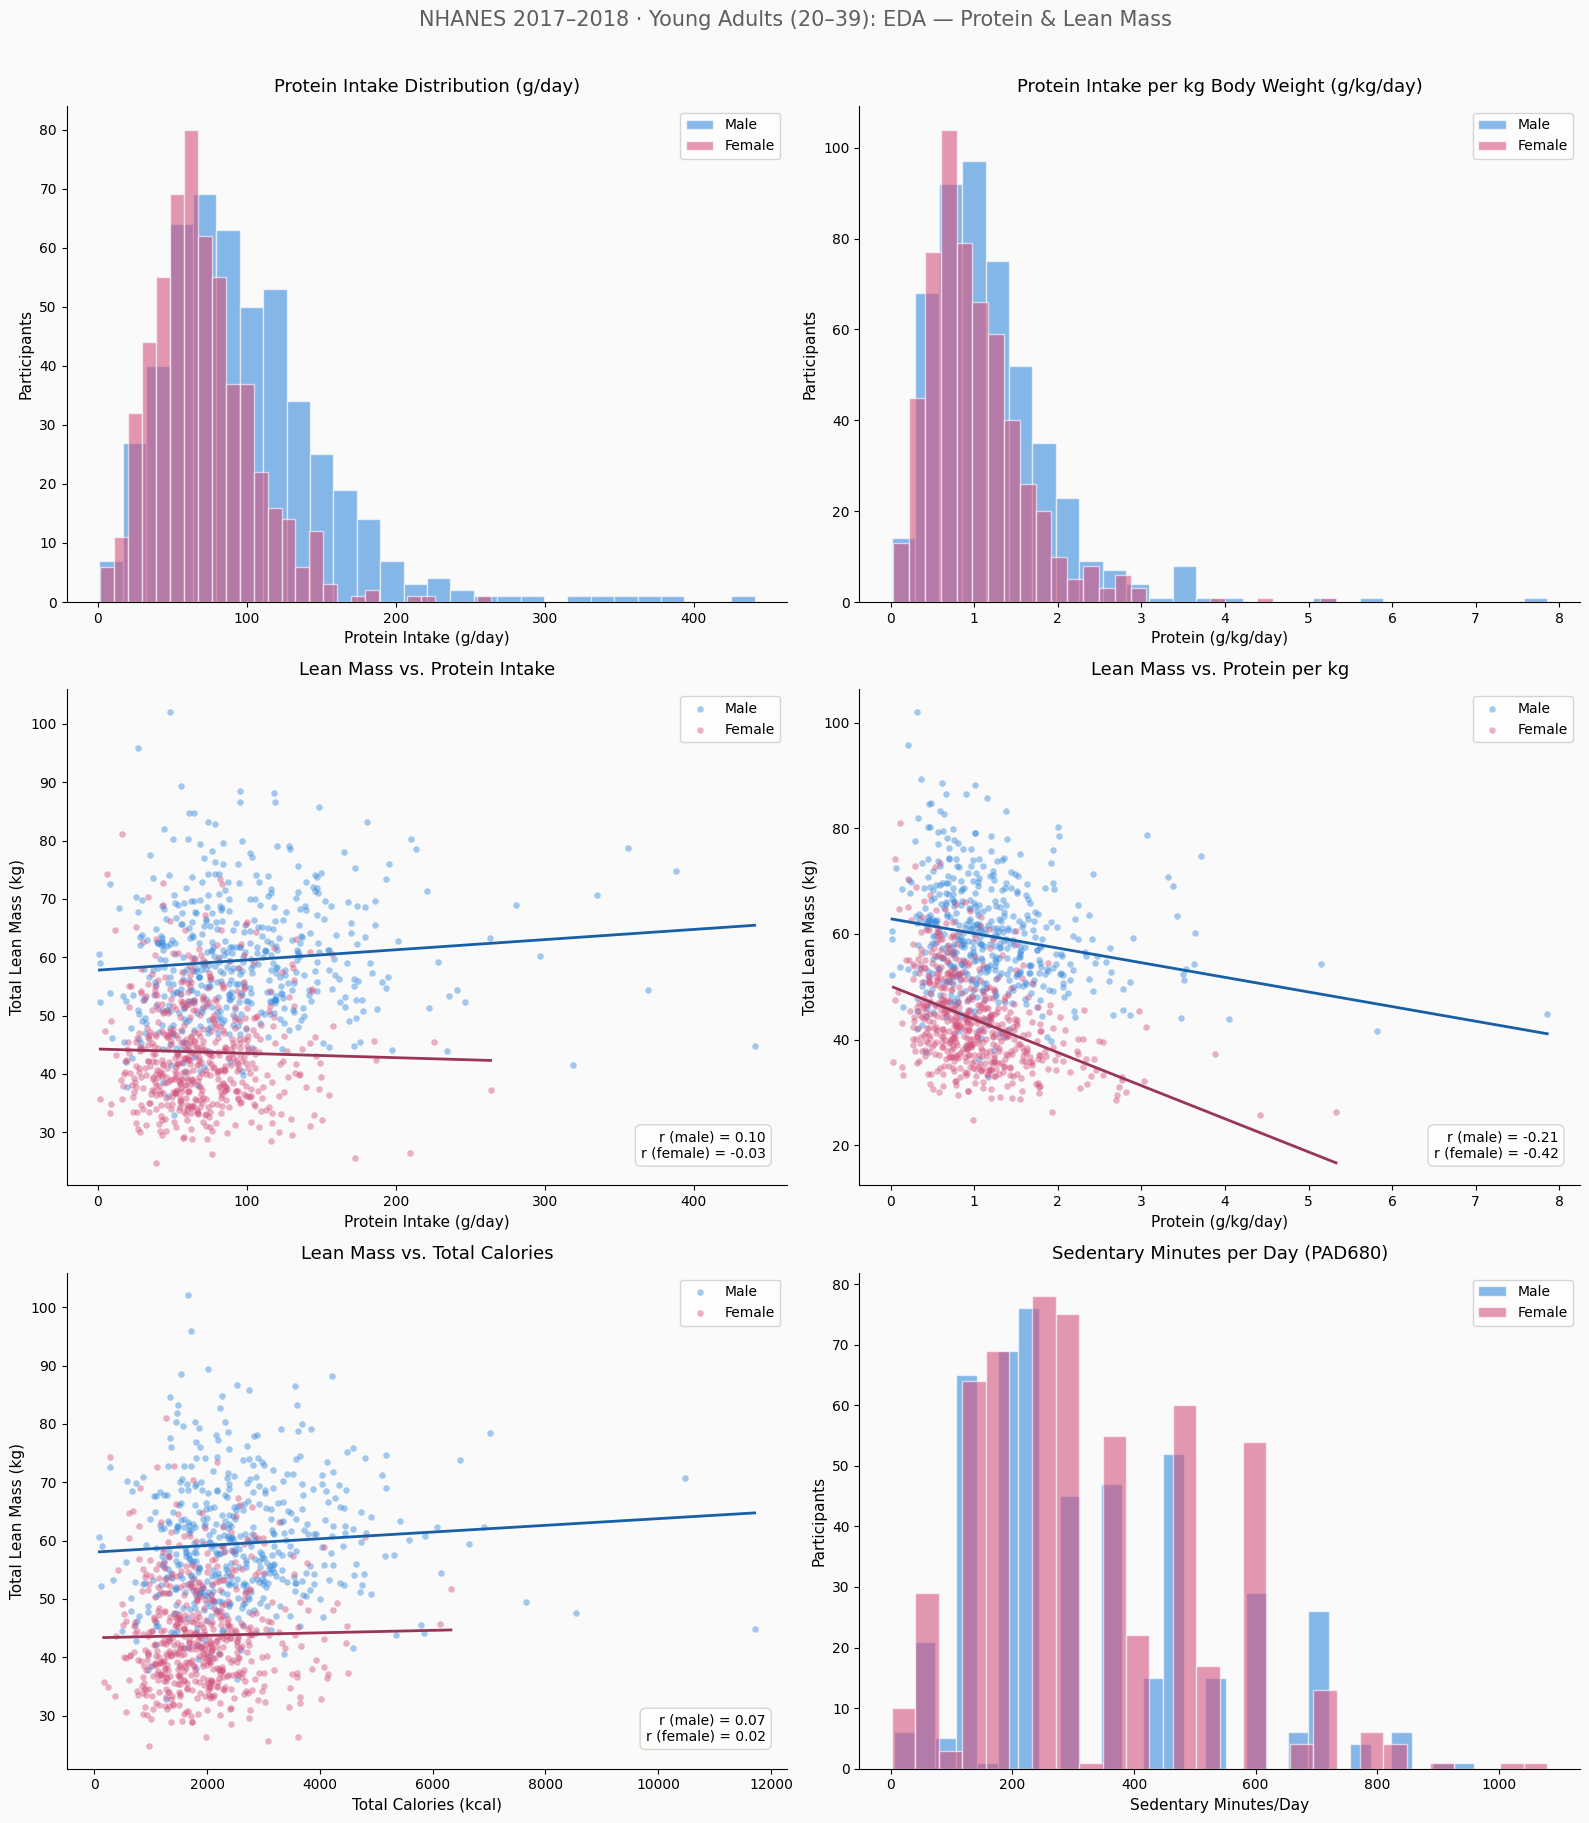

EDA plots saved.
Strongest Correlation


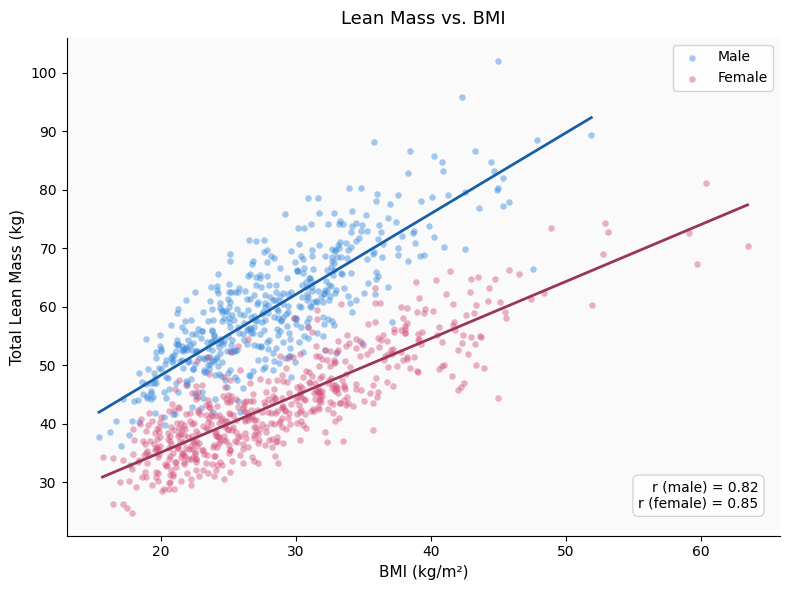

Weakest Correlation


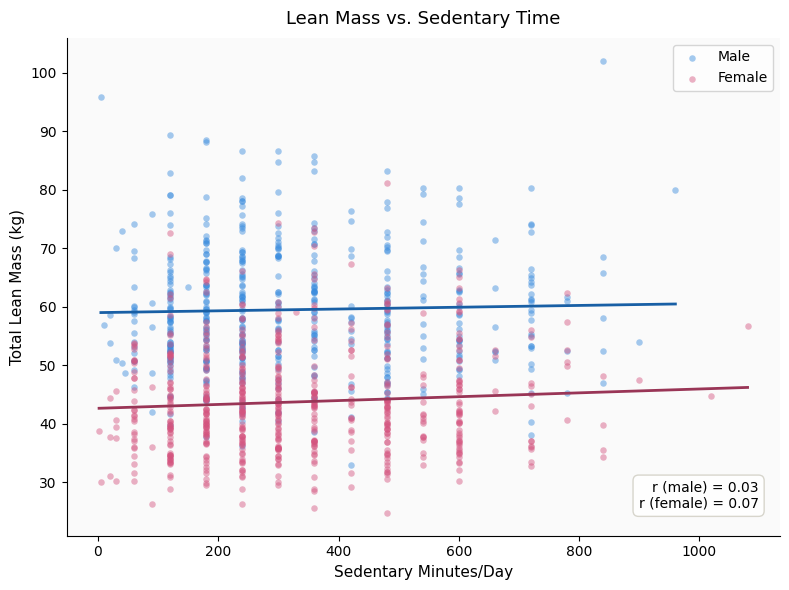

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.patch.set_facecolor('#FAFAFA')
axes = axes.flatten()
plt.suptitle('NHANES 2017–2018 · Young Adults (20–39): EDA — Protein & Lean Mass',
             fontsize=15, color='#5F5E5A', y=1.01)

def add_corr_box(ax, r_m, r_f):
    ax.text(0.97, 0.05, f'r (male) = {r_m:.2f}\nr (female) = {r_f:.2f}',
            transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D3D1C7', alpha=0.9))

def scatter_by_sex(ax, x_col, y_col, xlabel, title):
    for mask, color, label in [(m, male_color, 'Male'), (f, female_color, 'Female')]:
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   alpha=0.45, s=22, color=color, label=label, linewidths=0)
    for mask, color in [(m, '#185FA5'), (f, '#993556')]:
        xv = df.loc[mask, x_col].values
        yv = df.loc[mask, y_col].values
        coef, b = np.polyfit(xv, yv, 1)
        xl = np.linspace(xv.min(), xv.max(), 100)
        ax.plot(xl, coef*xl + b, color=color, linewidth=2)
    r_m = np.corrcoef(df.loc[m, x_col], df.loc[m, y_col])[0,1]
    r_f = np.corrcoef(df.loc[f, x_col], df.loc[f, y_col])[0,1]
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Total Lean Mass (kg)', fontsize=11)
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.set_facecolor('#FAFAFA')
    add_corr_box(ax, r_m, r_f)

# Plot 1: Protein distribution
axes[0].set_facecolor('#FAFAFA')
axes[0].hist(df.loc[m, 'DR1TPROT'], bins=28, color=male_color,   alpha=0.6, label='Male',   edgecolor='white')
axes[0].hist(df.loc[f, 'DR1TPROT'], bins=28, color=female_color, alpha=0.6, label='Female', edgecolor='white')
axes[0].set_title('Protein Intake Distribution (g/day)', fontsize=13, pad=10)
axes[0].set_xlabel('Protein Intake (g/day)', fontsize=11)
axes[0].set_ylabel('Participants', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Plot 2: Protein per kg distribution
axes[1].set_facecolor('#FAFAFA')
axes[1].hist(df.loc[m, 'protein_g_per_kg'], bins=28, color=male_color,   alpha=0.6, label='Male',   edgecolor='white')
axes[1].hist(df.loc[f, 'protein_g_per_kg'], bins=28, color=female_color, alpha=0.6, label='Female', edgecolor='white')
axes[1].set_title('Protein Intake per kg Body Weight (g/kg/day)', fontsize=13, pad=10)
axes[1].set_xlabel('Protein (g/kg/day)', fontsize=11)
axes[1].set_ylabel('Participants', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

# Plot 3–5: Scatter plots
scatter_by_sex(axes[2], 'DR1TPROT',      'target_lean_mass_kg', 'Protein Intake (g/day)',   'Lean Mass vs. Protein Intake')
scatter_by_sex(axes[3], 'protein_g_per_kg','target_lean_mass_kg','Protein (g/kg/day)',        'Lean Mass vs. Protein per kg')
scatter_by_sex(axes[4], 'DR1TKCAL',       'target_lean_mass_kg', 'Total Calories (kcal)',    'Lean Mass vs. Total Calories')

# Plot 6: Sedentary minutes distribution
axes[5].set_facecolor('#FAFAFA')
axes[5].hist(df.loc[m, 'PAD680'], bins=28, color=male_color,   alpha=0.6, label='Male',   edgecolor='white')
axes[5].hist(df.loc[f, 'PAD680'], bins=28, color=female_color, alpha=0.6, label='Female', edgecolor='white')
axes[5].set_title('Sedentary Minutes per Day (PAD680)', fontsize=13, pad=10)
axes[5].set_xlabel('Sedentary Minutes/Day', fontsize=11)
axes[5].set_ylabel('Participants', fontsize=11)
axes[5].legend(fontsize=10)
axes[5].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('nhanes_eda.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('EDA plots saved.')

# Figure: BMI vs Total Lean Mass
print('Strongest Correlation')
plt.figure(figsize=(8,6))

scatter_by_sex(
    plt.gca(),
    'BMI',
    'target_lean_mass_kg',
    'BMI (kg/m²)',
    'Lean Mass vs. BMI'
)

plt.tight_layout()
plt.show()

# Figure: Sedentary Time vs Total Lean Mass
print('Weakest Correlation')
plt.figure(figsize=(8,6))

scatter_by_sex(
    plt.gca(),
    'PAD680',
    'target_lean_mass_kg',
    'Sedentary Minutes/Day',
    'Lean Mass vs. Sedentary Time'
)

plt.tight_layout()
plt.show()

---
##Train / Validation / Test Split

In [ ]:
TARGET  = 'target_lean_mass_kg'


FEATS_BODYSIZE  = ['RIAGENDR', 'RIDAGEYR', 'BMXHT', 'BMXWT', 'BMI']

FEATS_BASELINE  = ['RIAGENDR', 'BMI']

FEATS_NUTRITION = FEATS_BODYSIZE + ['DR1TPROT', 'protein_g_per_kg', 'DR1TKCAL']
FEATS_ACTIVITY  = FEATS_NUTRITION + ['PAD680', 'PAQ650_binary']

all_needed = list(set(FEATS_ACTIVITY + FEATS_BASELINE + [TARGET]))
model_df   = df[all_needed].dropna().reset_index(drop=True)

X_all = model_df[FEATS_ACTIVITY]
y_all = model_df[TARGET]
strat = model_df['RIAGENDR']   # stratify by sex

# Step 1: carve out 30% (val + test)
X_train, X_tmp, y_train, y_tmp, s_train, s_tmp = train_test_split(
    X_all, y_all, strat,
    test_size=0.30, random_state=RANDOM_SEED, stratify=strat
)
# Step 2: split that 30% equally into val and test
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50, random_state=RANDOM_SEED, stratify=s_tmp
)

print(f'Total usable rows : {len(model_df)}')
print(f'Training set      : {len(X_train):>4}  ({len(X_train)/len(model_df)*100:.1f}%)')
print(f'Validation set    : {len(X_val):>4}  ({len(X_val)/len(model_df)*100:.1f}%)')
print(f'Test set          : {len(X_test):>4}  ({len(X_test)/len(model_df)*100:.1f}%)')
print()
for label, split_y, split_X in [('Train', y_train, X_train), ('Val', y_val, X_val), ('Test', y_test, X_test)]:
    n_m = (split_X['RIAGENDR']==1).sum()
    n_f = (split_X['RIAGENDR']==2).sum()
    print(f'{label:5s}: {n_m} males ({n_m/len(split_X)*100:.1f}%), {n_f} females ({n_f/len(split_X)*100:.1f}%)')


Total usable rows : 1057
Training set      :  739  (69.9%)
Validation set    :  159  (15.0%)
Test set          :  159  (15.0%)

Train: 343 males (46.4%), 396 females (53.6%)
Val  : 73 males (45.9%), 86 females (54.1%)
Test : 74 males (46.5%), 85 females (53.5%)


---
### Final Modeling-Table Summary


In [ ]:
print('FINAL MODELING-TABLE SUMMARY')
print('=' * 64)
print(f'Final rows (merged, age-filtered, cleaned)  : {len(df)}')
print(f'Rows used for modeling (== final rows here) : {len(model_df)}')
print(f'Target variable      : {TARGET}')
print('                        (Total Lean Mass, kg; DXA whole-body, excl. bone')
print('                         mineral content; same definition used everywhere)')
print(f'Predictor variables  : {", ".join(FEATS_ACTIVITY)}')
print(f'Train rows           : {len(X_train)}')
print(f'Validation rows      : {len(X_val)}')
print(f'Test rows            : {len(X_test)}')
print('Variables dropped for missingness : None — all planned predictors were')
print('                        kept; rows with missing values were dropped instead')
print('                        (see row counts in Section B).')
print('Special NHANES codes removed/recoded:')
print(f'  PAD680 : {{7777, 9999}} removed -> {n_removed_pad680} rows')
print(f'  PAQ650 : {{7, 9}} removed via mapping to NaN + dropna -> {n_removed_paq650} rows flagged')


FINAL MODELING-TABLE SUMMARY
Final rows (merged, age-filtered, cleaned)  : 1057
Rows used for modeling (== final rows here) : 1057
Target variable      : target_lean_mass_kg
                        (Total Lean Mass, kg; DXA whole-body, excl. bone
                         mineral content; same definition used everywhere)
Predictor variables  : RIAGENDR, RIDAGEYR, BMXHT, BMXWT, BMI, DR1TPROT, protein_g_per_kg, DR1TKCAL, PAD680, PAQ650_binary
Train rows           : 739
Validation rows      : 159
Test rows            : 159
Variables dropped for missingness : None — all planned predictors were
                        kept; rows with missing values were dropped instead
                        (see row counts in Section B).
Special NHANES codes removed/recoded:
  PAD680 : {7777, 9999} removed -> 3 rows
  PAQ650 : {7, 9} removed via mapping to NaN + dropna -> 0 rows flagged


---
## Section E: Baseline & Nested Linear Regression Models

In [ ]:
def evaluate(model, X, y):
    pred = model.predict(X)
    mae  = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2   = r2_score(y, pred)
    return mae, rmse, r2, pred

model_specs = [
    ('Baseline',    FEATS_BASELINE),
    ('+ Nutrition', FEATS_NUTRITION),
    ('+ Activity',  FEATS_ACTIVITY),
]

fitted_models = {}
results = []

for name, feats in model_specs:
    reg = LinearRegression()
    reg.fit(X_train[feats], y_train)
    fitted_models[name] = (reg, feats)

    tr_mae, tr_rmse, tr_r2, _  = evaluate(reg, X_train[feats], y_train)
    v_mae,  v_rmse,  v_r2,  _  = evaluate(reg, X_val[feats],   y_val)

    results.append({
        'Model':           name,
        'Train MAE':       round(tr_mae,  3),
        'Train RMSE':      round(tr_rmse, 3),
        'Train R²':        round(tr_r2,   3),
        'Validation MAE':  round(v_mae,   3),
        'Validation RMSE': round(v_rmse,  3),
        'Validation R²':   round(v_r2,    3),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Nested Model Comparison (Linear Regression) ===')
display(results_df)

=== Nested Model Comparison (Linear Regression) ===


,Train MAE,Train RMSE,Train R²,Validation MAE,Validation RMSE,Validation R²
Model,,,,,,
Baseline,4.206,5.337,0.813,4.678,5.952,0.797
+ Nutrition,2.379,3.030,0.940,2.618,3.493,0.930
+ Activity,2.313,2.935,0.944,2.605,3.405,0.933


In [ ]:
# interpretation of the nested comparison
base = results_df.loc['Baseline']
nutr = results_df.loc['+ Nutrition']
actv = results_df.loc['+ Activity']

print('--- Interpretation ---')
print(f'Adding nutrition variables changes validation RMSE by '
      f"{nutr['Validation RMSE'] - base['Validation RMSE']:+.3f} kg "
      f"and R² by {nutr['Validation R²'] - base['Validation R²']:+.3f}")
print(f'Adding activity variables (on top of nutrition) changes validation RMSE by '
      f"{actv['Validation RMSE'] - nutr['Validation RMSE']:+.3f} kg "
      f"and R² by {actv['Validation R²'] - nutr['Validation R²']:+.3f}")
print()
print('Note: A small change in R² after adding protein suggests that body size (sex, height,\n'
      'weight, BMI) explains most of the variance in lean mass. This is expected in\n'
      'cross-sectional data and does not mean protein is unimportant — it means the\n'
      'association is partially captured by body weight already.')

--- Interpretation ---
Adding nutrition variables changes validation RMSE by -2.459 kg and R² by +0.133
Adding activity variables (on top of nutrition) changes validation RMSE by -0.088 kg and R² by +0.003

Note: A small change in R² after adding protein suggests that body size (sex, height,
weight, BMI) explains most of the variance in lean mass. This is expected in
cross-sectional data and does not mean protein is unimportant — it means the
association is partially captured by body weight already.


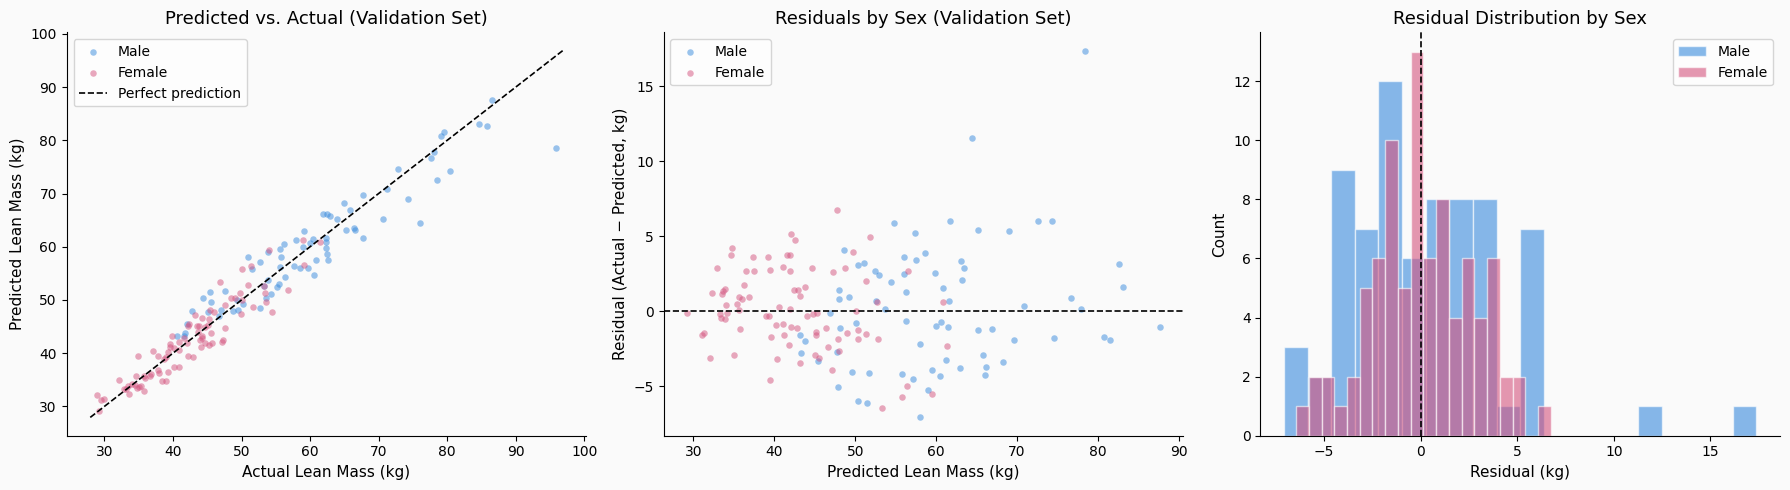

Residual summary (Validation Set):
  Male  : mean=+0.243 kg, std=4.132 kg, MAE=3.164 kg
  Female: mean=+0.099 kg, std=2.676 kg, MAE=2.131 kg


In [ ]:
best_name  = '+ Activity'
best_model, best_feats = fitted_models[best_name]

_, _, _, y_val_pred  = evaluate(best_model, X_val[best_feats],  y_val)
_, _, _, y_train_pred = evaluate(best_model, X_train[best_feats], y_train)

residuals_val = y_val - y_val_pred

# Sex masks on validation set
val_m = X_val['RIAGENDR'] == 1
val_f = X_val['RIAGENDR'] == 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FAFAFA')

# --- Plot A: Predicted vs Actual ---
ax = axes[0]
ax.set_facecolor('#FAFAFA')
ax.scatter(y_val[val_m], y_val_pred[val_m], alpha=0.5, s=22, color='#378ADD', label='Male',   linewidths=0)
ax.scatter(y_val[val_f], y_val_pred[val_f], alpha=0.5, s=22, color='#D4537E', label='Female', linewidths=0)
lo = min(y_val.min(), y_val_pred.min()) - 1
hi = max(y_val.max(), y_val_pred.max()) + 1
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual Lean Mass (kg)', fontsize=11)
ax.set_ylabel('Predicted Lean Mass (kg)', fontsize=11)
ax.set_title('Predicted vs. Actual (Validation Set)', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# --- Plot B: Residuals by Sex (validation) ---
ax = axes[1]
ax.set_facecolor('#FAFAFA')
ax.scatter(y_val_pred[val_m], residuals_val[val_m], alpha=0.5, s=22, color='#378ADD', label='Male',   linewidths=0)
ax.scatter(y_val_pred[val_f], residuals_val[val_f], alpha=0.5, s=22, color='#D4537E', label='Female', linewidths=0)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Predicted Lean Mass (kg)', fontsize=11)
ax.set_ylabel('Residual (Actual − Predicted, kg)', fontsize=11)
ax.set_title('Residuals by Sex (Validation Set)', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

# --- Plot C: Residual distribution by sex ---
ax = axes[2]
ax.set_facecolor('#FAFAFA')
ax.hist(residuals_val[val_m], bins=20, color='#378ADD', alpha=0.6, label='Male',   edgecolor='white')
ax.hist(residuals_val[val_f], bins=20, color='#D4537E', alpha=0.6, label='Female', edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Residual (kg)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Residual Distribution by Sex', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('nhanes_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

# --- Residual summary by sex ---
print('Residual summary (Validation Set):')
for label, mask in [('Male', val_m), ('Female', val_f)]:
    r = residuals_val[mask]
    print(f'  {label:6s}: mean={r.mean():+.3f} kg, std={r.std():.3f} kg, MAE={r.abs().mean():.3f} kg')

In [ ]:
print('=== Training vs Validation Metrics (Overfitting Check) ===')
ov_rows = []
for name, (reg, feats) in fitted_models.items():
    tr_mae, tr_rmse, tr_r2, _ = evaluate(reg, X_train[feats], y_train)
    v_mae,  v_rmse,  v_r2,  _ = evaluate(reg, X_val[feats],   y_val)
    ov_rows.append({
        'Model': name,
        'Train RMSE': round(tr_rmse, 3),
        'Val RMSE':   round(v_rmse,  3),
        'ΔRMSE (Val−Train)': round(v_rmse - tr_rmse, 3),
        'Train R²': round(tr_r2, 3),
        'Val R²':   round(v_r2,  3),
    })
display(pd.DataFrame(ov_rows).set_index('Model'))
print('\nSmall ΔRMSE values indicate no significant overfitting.')

=== Training vs Validation Metrics (Overfitting Check) ===


,Train RMSE,Val RMSE,ΔRMSE (Val−Train),Train R²,Val R²
Model,,,,,
Baseline,5.337,5.952,0.616,0.813,0.797
+ Nutrition,3.030,3.493,0.463,0.940,0.930
+ Activity,2.935,3.405,0.470,0.944,0.933



Small ΔRMSE values indicate no significant overfitting.


In [ ]:
final_model, final_feats = fitted_models['+ Activity']

t_mae, t_rmse, t_r2, y_test_pred = evaluate(final_model, X_test[final_feats], y_test)

print('=== Final Model (+ Activity) — Test Set Results ===')
print(f'  MAE  : {t_mae:.3f} kg')
print(f'  RMSE : {t_rmse:.3f} kg')
print(f'  R²   : {t_r2:.3f}')
print()
print('These results were produced on data the model has never seen.')
print('They should be close to the validation results above; a large gap would indicate overfitting.')

=== Final Model (+ Activity) — Test Set Results ===
  MAE  : 2.414 kg
  RMSE : 3.027 kg
  R²   : 0.935

These results were produced on data the model has never seen.
They should be close to the validation results above; a large gap would indicate overfitting.


---
##Improved Model — Random Forest Regressor

In [ ]:

from sklearn.ensemble import RandomForestRegressor
import itertools

MAX_DEPTHS    = [3, 5, 8, 12, None]   # None = fully grown (default, prone to overfit)
N_ESTIMATORS  = [50, 100, 200, 300]

tune_rows = []
for max_depth, n_est in itertools.product(MAX_DEPTHS, N_ESTIMATORS):
    rf_tmp = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=max_depth,
        max_features='sqrt',
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf_tmp.fit(X_train[FEATS_ACTIVITY], y_train)
    tr_mae, tr_rmse, tr_r2, _ = evaluate(rf_tmp, X_train[FEATS_ACTIVITY], y_train)
    v_mae,  v_rmse,  v_r2,  _ = evaluate(rf_tmp, X_val[FEATS_ACTIVITY],   y_val)
    tune_rows.append({
        'max_depth':       str(max_depth) if max_depth is not None else 'None (full)',
        'n_estimators':    n_est,
        'Train RMSE':      round(tr_rmse, 3),
        'Val RMSE':        round(v_rmse,  3),
        'ΔRMSE (overfit)': round(v_rmse - tr_rmse, 3),
        'Val R²':          round(v_r2,   3),
    })

tune_df = pd.DataFrame(tune_rows)
print('=== Hyperparameter Tuning Grid (Validation Set) ===')
display(tune_df.sort_values(['Val RMSE', 'ΔRMSE (overfit)']))

# Best config: lowest Val RMSE (primary), then smallest overfit gap (tiebreak)
best_row = tune_df.sort_values(['Val RMSE', 'ΔRMSE (overfit)']).iloc[0]
BEST_MAX_DEPTH   = None if best_row['max_depth'] == 'None (full)' else int(best_row['max_depth'])
BEST_N_EST       = int(best_row['n_estimators'])
print(f"\n✓ Best config → max_depth={BEST_MAX_DEPTH}, n_estimators={BEST_N_EST}")
print(f"  Val RMSE={best_row['Val RMSE']:.3f} kg,  Overfit gap={best_row['ΔRMSE (overfit)']:.3f} kg")


=== Hyperparameter Tuning Grid (Validation Set) ===


,max_depth,n_estimators,Train RMSE,Val RMSE,ΔRMSE (overfit),Val R²
18,None (full),200,2.577,4.005,1.428,0.908
14,12,200,2.578,4.016,1.438,0.907
11,8,300,2.642,4.044,1.402,0.906
19,None (full),300,2.580,4.044,1.464,0.906
10,8,200,2.634,4.045,1.411,0.906
15,12,300,2.580,4.050,1.470,0.906
8,8,50,2.656,4.057,1.401,0.906
17,None (full),100,2.630,4.058,1.428,0.906
16,None (full),50,2.675,4.063,1.388,0.905
13,12,100,2.632,4.071,1.439,0.905



✓ Best config → max_depth=None, n_estimators=200
  Val RMSE=4.005 kg,  Overfit gap=1.428 kg


In [ ]:


rf_model = RandomForestRegressor(
    n_estimators=BEST_N_EST,
    max_depth=BEST_MAX_DEPTH,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train[FEATS_ACTIVITY], y_train)

rf_tr_mae,  rf_tr_rmse,  rf_tr_r2,  _             = evaluate(rf_model, X_train[FEATS_ACTIVITY], y_train)
rf_val_mae, rf_val_rmse, rf_val_r2, y_val_pred_rf  = evaluate(rf_model, X_val[FEATS_ACTIVITY],   y_val)

print(f'=== Final Random Forest (max_depth={BEST_MAX_DEPTH}, n_estimators={BEST_N_EST}) — Validation Set ===')
print(f'  Train  :  MAE={rf_tr_mae:.3f} kg  RMSE={rf_tr_rmse:.3f} kg  R²={rf_tr_r2:.3f}')
print(f'  Val    :  MAE={rf_val_mae:.3f} kg  RMSE={rf_val_rmse:.3f} kg  R²={rf_val_r2:.3f}')
print(f'  ΔVal−Train RMSE = {rf_val_rmse - rf_tr_rmse:+.3f} kg  (small = no significant overfitting)')


=== Final Random Forest (max_depth=None, n_estimators=200) — Validation Set ===
  Train  :  MAE=1.890 kg  RMSE=2.577 kg  R²=0.956
  Val    :  MAE=3.070 kg  RMSE=4.005 kg  R²=0.908
  ΔVal−Train RMSE = +1.428 kg  (small = no significant overfitting)


In [ ]:
# ── Head-to-head comparison: all linear models + Random Forest ─────────────────
lr_best = results_df.loc['+ Activity']

compare_rows = []
for row in results_df.reset_index().to_dict('records'):
    compare_rows.append({
        'Model':           row['Model'] + '  (Linear)',
        'Val MAE (kg)':    row['Validation MAE'],
        'Val RMSE (kg)':   row['Validation RMSE'],
        'Val R²':          row['Validation R²'],
    })

compare_rows.append({
    'Model':         'Random Forest  (all features)',
    'Val MAE (kg)':  round(rf_val_mae,  3),
    'Val RMSE (kg)': round(rf_val_rmse, 3),
    'Val R²':        round(rf_val_r2,   3),
})

compare_df = pd.DataFrame(compare_rows).set_index('Model')
print('=== All-Model Comparison (Validation Set) ===')
display(compare_df)

# Improvement over best linear model
delta_mae  = rf_val_mae  - lr_best['Validation MAE']
delta_rmse = rf_val_rmse - lr_best['Validation RMSE']
delta_r2   = rf_val_r2   - lr_best['Validation R²']
print(f'\nRandom Forest vs. Best Linear Model (+ Activity):')
print(f'  ΔMAE  = {delta_mae:+.3f} kg')
print(f'  ΔRMSE = {delta_rmse:+.3f} kg')
print(f'  ΔR²   = {delta_r2:+.4f}')
if rf_val_mae < lr_best['Validation MAE']:
    print('  ✓ Random Forest improves on the best linear model.')
else:
    print('  Note: Linear and RF models are closely matched — body size dominates prediction.')


=== All-Model Comparison (Validation Set) ===


,Val MAE (kg),Val RMSE (kg),Val R²
Model,,,
Baseline (Linear),4.678,5.952,0.797
+ Nutrition (Linear),2.618,3.493,0.930
+ Activity (Linear),2.605,3.405,0.933
Random Forest (all features),3.070,4.005,0.908



Random Forest vs. Best Linear Model (+ Activity):
  ΔMAE  = +0.465 kg
  ΔRMSE = +0.600 kg
  ΔR²   = -0.0250
  Note: Linear and RF models are closely matched — body size dominates prediction.


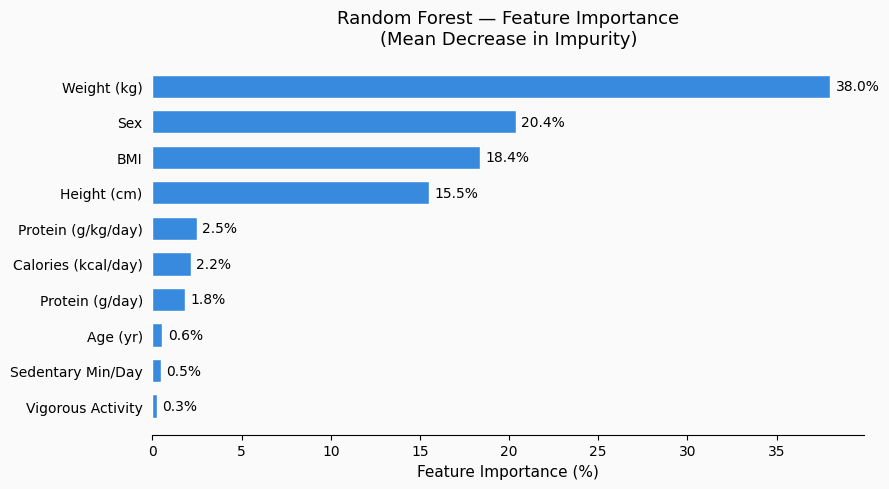

Feature importance plot saved.


In [ ]:
# ── Feature importance plot ────────────────────────────────────────────────────
feat_names_display = {
    'RIAGENDR':       'Sex',
    'RIDAGEYR':       'Age (yr)',
    'BMXHT':          'Height (cm)',
    'BMXWT':          'Weight (kg)',
    'BMI':            'BMI',
    'DR1TPROT':       'Protein (g/day)',
    'protein_g_per_kg': 'Protein (g/kg/day)', #protein per kilogram of weight per day
    'DR1TKCAL':       'Calories (kcal/day)',
    'PAD680':         'Sedentary Min/Day',
    'PAQ650_binary':  'Vigorous Activity',
}

importances = pd.Series(rf_model.feature_importances_, index=FEATS_ACTIVITY)
importances = importances.rename(feat_names_display).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
bars = ax.barh(importances.index, importances.values * 100,
               color='#378ADD', edgecolor='white', height=0.65)
for bar, val in zip(bars, importances.values * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Feature Importance (%)', fontsize=11)
ax.set_title('Random Forest — Feature Importance\n(Mean Decrease in Impurity)', fontsize=13, pad=10)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.savefig('nhanes_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Feature importance plot saved.')


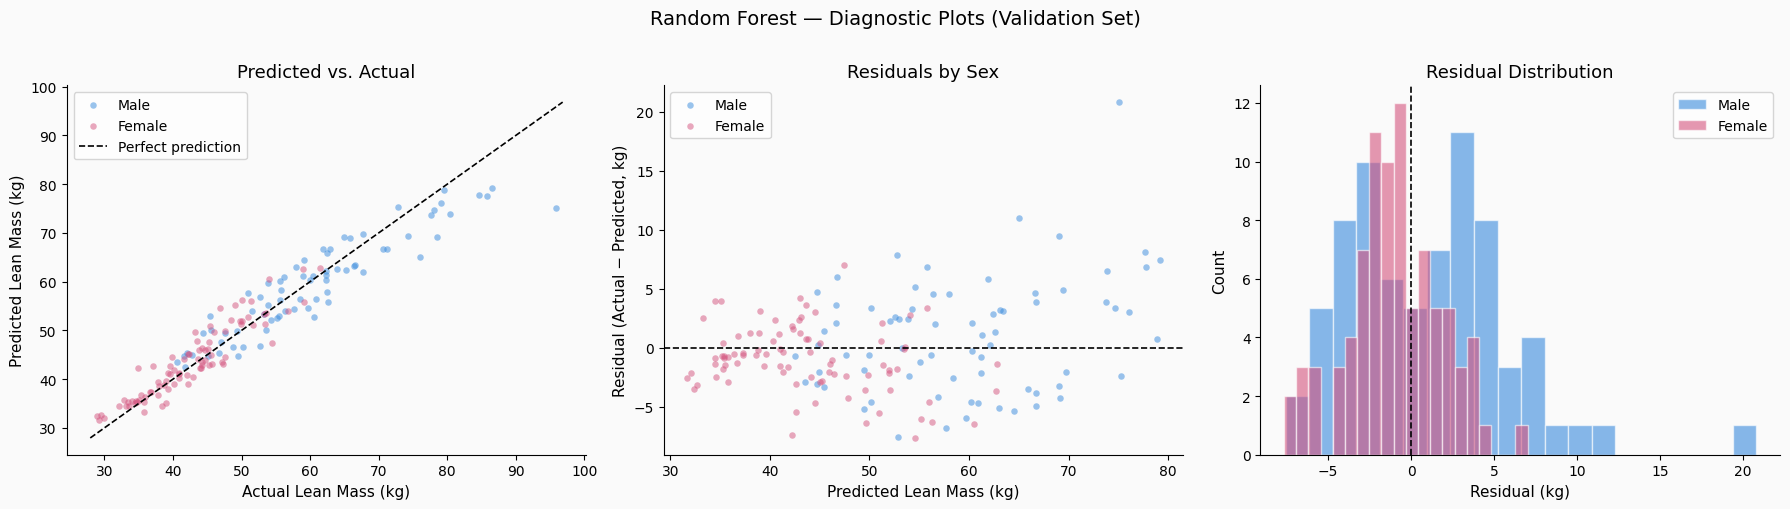

Residual summary — Random Forest (Validation Set):
  Male  : mean=+1.037 kg, std=4.856 kg, MAE=3.883 kg
  Female: mean=-0.993 kg, std=2.847 kg, MAE=2.380 kg


In [ ]:
# ── Residual diagnostics for Random Forest ────────────────────────────────────
residuals_rf_val = y_val - y_val_pred_rf
val_m = X_val['RIAGENDR'] == 1
val_f = X_val['RIAGENDR'] == 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FAFAFA')
plt.suptitle('Random Forest — Diagnostic Plots (Validation Set)', fontsize=14, y=1.01)

# A: Predicted vs Actual
ax = axes[0]; ax.set_facecolor('#FAFAFA')
ax.scatter(y_val[val_m], y_val_pred_rf[val_m], alpha=0.5, s=22, color='#378ADD', label='Male',   linewidths=0)
ax.scatter(y_val[val_f], y_val_pred_rf[val_f], alpha=0.5, s=22, color='#D4537E', label='Female', linewidths=0)
lo = min(y_val.min(), y_val_pred_rf.min()) - 1
hi = max(y_val.max(), y_val_pred_rf.max()) + 1
ax.plot([lo,hi],[lo,hi],'k--',linewidth=1.2,label='Perfect prediction')
ax.set_xlabel('Actual Lean Mass (kg)',fontsize=11)
ax.set_ylabel('Predicted Lean Mass (kg)',fontsize=11)
ax.set_title('Predicted vs. Actual',fontsize=13)
ax.legend(fontsize=10); ax.spines[['top','right']].set_visible(False)

# B: Residuals vs Predicted
ax = axes[1]; ax.set_facecolor('#FAFAFA')
ax.scatter(y_val_pred_rf[val_m], residuals_rf_val[val_m], alpha=0.5, s=22, color='#378ADD', label='Male',   linewidths=0)
ax.scatter(y_val_pred_rf[val_f], residuals_rf_val[val_f], alpha=0.5, s=22, color='#D4537E', label='Female', linewidths=0)
ax.axhline(0,color='black',linewidth=1.2,linestyle='--')
ax.set_xlabel('Predicted Lean Mass (kg)',fontsize=11)
ax.set_ylabel('Residual (Actual − Predicted, kg)',fontsize=11)
ax.set_title('Residuals by Sex',fontsize=13)
ax.legend(fontsize=10); ax.spines[['top','right']].set_visible(False)

# C: Residual histogram
ax = axes[2]; ax.set_facecolor('#FAFAFA')
ax.hist(residuals_rf_val[val_m],bins=20,color='#378ADD',alpha=0.6,label='Male',   edgecolor='white')
ax.hist(residuals_rf_val[val_f],bins=20,color='#D4537E',alpha=0.6,label='Female', edgecolor='white')
ax.axvline(0,color='black',linewidth=1.2,linestyle='--')
ax.set_xlabel('Residual (kg)',fontsize=11); ax.set_ylabel('Count',fontsize=11)
ax.set_title('Residual Distribution',fontsize=13)
ax.legend(fontsize=10); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('nhanes_rf_diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print('Residual summary — Random Forest (Validation Set):')
for label, mask in [('Male', val_m), ('Female', val_f)]:
    r = residuals_rf_val[mask]
    print(f'  {label:6s}: mean={r.mean():+.3f} kg, std={r.std():.3f} kg, MAE={r.abs().mean():.3f} kg')


In [ ]:
# ── Final evaluation on held-out test set (Random Forest) ─────────────────────

rf_t_mae, rf_t_rmse, rf_t_r2, y_test_pred_rf = evaluate(rf_model, X_test[FEATS_ACTIVITY], y_test)

print('=== Random Forest — Test Set Results (held-out) ===')
print(f'  MAE  : {rf_t_mae:.3f} kg')
print(f'  RMSE : {rf_t_rmse:.3f} kg')
print(f'  R²   : {rf_t_r2:.3f}')
print()
print('Linear (+ Activity) test set for reference:')
lr_t_mae, lr_t_rmse, lr_t_r2, _ = evaluate(fitted_models['+ Activity'][0],
                                             X_test[FEATS_ACTIVITY], y_test)
print(f'  MAE  : {lr_t_mae:.3f} kg   RMSE : {lr_t_rmse:.3f} kg   R² : {lr_t_r2:.3f}')
print()
rf_gap_mae  = rf_t_mae  - rf_val_mae
rf_gap_rmse = rf_t_rmse - rf_val_rmse
print(f'RF Val→Test gap:  ΔMAE={rf_gap_mae:+.3f} kg, ΔRMSE={rf_gap_rmse:+.3f} kg')
if abs(rf_gap_rmse) < 0.5:
    print('  ✓ Generalisation looks stable — small val→test gap.')
else:
    print('  ⚠ Larger-than-expected gap. Review for overfitting.')


=== Random Forest — Test Set Results (held-out) ===
  MAE  : 2.499 kg
  RMSE : 3.218 kg
  R²   : 0.926

Linear (+ Activity) test set for reference:
  MAE  : 2.414 kg   RMSE : 3.027 kg   R² : 0.935

RF Val→Test gap:  ΔMAE=-0.571 kg, ΔRMSE=-0.787 kg
  ⚠ Larger-than-expected gap. Review for overfitting.


In [ ]:
style  = {'description_width': '160px'}
layout = widgets.Layout(width='380px')

age_w       = widgets.IntSlider(value=25, min=20, max=39, description='Age (years):', style=style, layout=layout)
sex_w       = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Sex:', style=style, layout=layout)
height_w    = widgets.FloatSlider(value=178.0, min=140.0, max=210.0, step=0.5, description='Height (cm):', style=style, layout=layout)
weight_w    = widgets.FloatSlider(value=75.0, min=40.0, max=180.0, step=0.5, description='Weight (kg):', style=style, layout=layout)
protein_w   = widgets.FloatSlider(value=110.0, min=20.0, max=300.0, step=5.0, description='Protein intake (g/day):', style=style, layout=layout)
calories_w  = widgets.FloatSlider(value=2400.0, min=800.0, max=5000.0, step=50.0, description='Calories (kcal/day):', style=style, layout=layout)
sedentary_w = widgets.FloatSlider(value=360.0, min=0.0, max=1380.0, step=10.0, description='Sedentary min/day:', style=style, layout=layout)
vigorous_w  = widgets.Dropdown(options=['Yes', 'No'], value='Yes', description='Vigorous activity:', style=style, layout=layout)

predict_btn = widgets.Button(description='Predict Lean Mass', button_style='primary', icon='calculator',
                              layout=widgets.Layout(width='240px', height='44px', margin='4px 0 0 0'))
output_area = widgets.Output(layout=widgets.Layout(
    border_top='1px solid #E0E0E0', margin='18px 0 0 0', padding='14px 4px 4px 4px'))


def build_input_row(sex_label, age, height_cm, weight_kg, protein_g_day,
                     calories_kcal, sedentary_min, vigorous_activity):
    bmi            = weight_kg / (height_cm / 100) ** 2
    protein_per_kg = protein_g_day / weight_kg
    sex_code       = 1.0 if sex_label == 'Male' else 2.0
    vigorous_code  = 1.0 if vigorous_activity == 'Yes' else 0.0
    row = pd.DataFrame([{
        'RIAGENDR': sex_code, 'RIDAGEYR': float(age), 'BMXHT': height_cm,
        'BMXWT': weight_kg, 'BMI': bmi, 'DR1TPROT': protein_g_day,
        'protein_g_per_kg': protein_per_kg, 'DR1TKCAL': calories_kcal,
        'PAD680': sedentary_min, 'PAQ650_binary': vigorous_code,
    }])[FEATS_ACTIVITY]
    return row, bmi, protein_per_kg, sex_code


def on_predict_click(_):
    with output_area:
        clear_output(wait=True)

        age, sex             = age_w.value, sex_w.value
        height_cm, weight_kg = height_w.value, weight_w.value
        protein_g_day        = protein_w.value
        calories_kcal        = calories_w.value
        sedentary_min        = sedentary_w.value
        vigorous_activity    = vigorous_w.value

        user_input, bmi, protein_per_kg, sex_code = build_input_row(
            sex, age, height_cm, weight_kg, protein_g_day,
            calories_kcal, sedentary_min, vigorous_activity)

        predicted_lean_mass = rf_model.predict(user_input)[0]
        lower_bound = predicted_lean_mass - rf_val_mae
        upper_bound = predicted_lean_mass + rf_val_mae

        same_sex_mask = model_df['RIAGENDR'] == sex_code
        same_sex_lean = model_df.loc[same_sex_mask, 'target_lean_mass_kg']
        percentile    = int((same_sex_lean < predicted_lean_mass).mean() * 100)

        nhanes_prot = model_df.loc[same_sex_mask, 'DR1TPROT'].mean()
        nhanes_kcal = model_df.loc[same_sex_mask, 'DR1TKCAL'].mean()
        nhanes_wt   = model_df.loc[same_sex_mask, 'BMXWT'].mean()
        nhanes_lean = same_sex_lean.mean()

        SEP, SEP2 = '=' * 64, '-' * 64
        print(SEP)
        print('   NHANES LEAN MASS PREDICTION DASHBOARD (Random Forest model)')
        print(SEP)
        print()
        print('IMPORTANT: This is an association-based prediction from a model')
        print('trained on cross-sectional NHANES data. It is NOT medical,')
        print('diagnostic, or athletic-training advice, and a change in any one')
        print('input does not mean that change would CAUSE the predicted result')
        print('in a real person.')
        print()
        print('YOUR INPUTS')
        print(SEP2)
        print(f'  Age               : {age} years')
        print(f'  Sex               : {sex}')
        print(f'  Height            : {height_cm:.1f} cm')
        print(f'  Weight            : {weight_kg:.1f} kg')
        print(f'  BMI               : {bmi:.1f}')
        print(f'  Protein intake    : {protein_g_day:.0f} g/day  ({protein_per_kg:.2f} g/kg/day)')
        print(f'  Calories          : {calories_kcal:.0f} kcal/day')
        print(f'  Sedentary minutes : {sedentary_min:.0f} min/day')
        print(f'  Vigorous activity : {vigorous_activity}')
        print()
        print(SEP)
        print('PREDICTION  (Total Lean Mass)')
        print(SEP)
        print(f'  Predicted total lean mass  : {predicted_lean_mass:.1f} kg')
        print(f'  Typical model error (±MAE) : {rf_val_mae:.2f} kg  '
              f'(range ≈ {lower_bound:.1f}-{upper_bound:.1f} kg)')
        print(f'  Population percentile      : {percentile}th, vs. same-sex NHANES '
              f'{sex.lower()}s aged 20-39')
        print()
        print(SEP)
        print('COMPARISON TO NHANES AVERAGE (same-sex, 20-39 yrs)')
        print(SEP)
        print(f'  {"Variable":<20}{"You":>15}{"NHANES avg":>18}')
        print(f'  {"Protein (g/day)":<20}{protein_g_day:>15.0f}{nhanes_prot:>18.0f}')
        print(f'  {"Calories (kcal/day)":<20}{calories_kcal:>15.0f}{nhanes_kcal:>18.0f}')
        print(f'  {"Weight (kg)":<20}{weight_kg:>15.1f}{nhanes_wt:>18.1f}')
        print(f'  {"Lean mass (kg)":<20}{predicted_lean_mass:>15.1f}{nhanes_lean:>18.1f}')
        print()

        # ── Feature importance (model-level, not personalized) ───────────────
        print(SEP)
        print('FEATURE IMPORTANCE  (Random Forest, overall model)')
        print(SEP)
        feat_imp_display = {
            'RIAGENDR': 'Sex', 'RIDAGEYR': 'Age', 'BMXHT': 'Height', 'BMXWT': 'Weight',
            'BMI': 'BMI', 'DR1TPROT': 'Protein intake', 'protein_g_per_kg': 'Protein (g/kg)',
            'DR1TKCAL': 'Calories', 'PAD680': 'Sedentary min/day', 'PAQ650_binary': 'Vigorous activity',
        }
        imp_sorted = sorted(zip(FEATS_ACTIVITY, rf_model.feature_importances_),
                             key=lambda x: x[1], reverse=True)
        for rank, (feat, imp) in enumerate(imp_sorted, 1):
            bar = '█' * int(imp * 200)
            print(f'  {rank:2d}. {feat_imp_display[feat]:<18s} {bar:<20s} {imp*100:5.1f}%')
        print()

        # ── Protein sensitivity, framed as association not causation ─────────
        delta_g = 20.0
        alt_row, *_ = build_input_row(sex, age, height_cm, weight_kg, protein_g_day + delta_g,
                                       calories_kcal, sedentary_min, vigorous_activity)
        pred_alt = rf_model.predict(alt_row)[0]
        print(SEP)
        print('PROTEIN SENSITIVITY  (association-based, not a causal estimate)')
        print(SEP)
        print(f'  In this model, changing protein intake from {protein_g_day:.0f} g/day to '
              f'{protein_g_day + delta_g:.0f} g/day')
        print(f'  changes the predicted lean mass from {predicted_lean_mass:.1f} kg to '
              f'{pred_alt:.1f} kg (Δ = {pred_alt - predicted_lean_mass:+.2f} kg),')
        print('  holding all other inputs fixed. NHANES is cross-sectional, so this is')
        print('  an association captured by the model, not evidence that raising protein')
        print('  would cause this change in any individual.')
        print()

        # ── What-if curve across a range of protein intakes ──────────────────
        protein_range = np.arange(50, 251, 5)
        preds_whatif = []
        for p in protein_range:
            r, *_ = build_input_row(sex, age, height_cm, weight_kg, p,
                                     calories_kcal, sedentary_min, vigorous_activity)
            preds_whatif.append(rf_model.predict(r)[0])
        preds_whatif = np.array(preds_whatif)

        fig, ax = plt.subplots(figsize=(9, 4.5))
        fig.patch.set_facecolor('#FAFAFA'); ax.set_facecolor('#FAFAFA')
        ax.plot(protein_range, preds_whatif, color='#378ADD', linewidth=2.5,
                label='Model-predicted lean mass')
        ax.axvline(protein_g_day, color='#D4537E', linewidth=1.8, linestyle='--',
                   label=f'Your intake ({protein_g_day:.0f} g/day)')
        ax.scatter([protein_g_day], [predicted_lean_mass], color='#D4537E', s=80, zorder=5)
        ax.fill_between(protein_range, preds_whatif - rf_val_mae, preds_whatif + rf_val_mae,
                         alpha=0.15, color='#378ADD', label=f'±MAE band ({rf_val_mae:.2f} kg)')
        ax.set_xlabel('Daily Protein Intake (g/day)', fontsize=11)
        ax.set_ylabel('Predicted Total Lean Mass (kg)', fontsize=11)
        ax.set_title(f'Association between Protein Intake and Predicted Lean Mass\n'
                     f'({sex}, {age} yr, {height_cm:.0f} cm, {weight_kg:.0f} kg) — '
                     f'an association, not a causal effect', fontsize=11, pad=10)
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.show()


predict_btn.on_click(on_predict_click)

# ── Nicer layout: color-coded, bordered "cards" grouping related inputs ────
def section_header(emoji, title, color):
    return widgets.HTML(
        f"<div style='font-size:14px; font-weight:700; letter-spacing:.2px; "
        f"color:{color}; margin:0 0 10px 0; padding-bottom:6px; "
        f"border-bottom:2px solid {color};'>{emoji}&nbsp; {title}</div>"
    )

def card(children, accent):
    return widgets.VBox(
        children,
        layout=widgets.Layout(
            border_left=f'4px solid {accent}',
            padding='14px 18px 16px 16px', margin='0 14px 16px 0',
            width='416px',
        )
    )

title_html = widgets.HTML(
    "<div style='font-size:21px; font-weight:700; color:#2F2F2F; "
    "margin:2px 0 2px 0;'>🎯 NHANES Lean Mass Predictor</div>"
    "<div style='font-size:13px; color:#8A8A8A; margin-bottom:6px;'>"
    "Random Forest model · trained on NHANES 2017–2018, ages 20–39</div>"
)

body_card      = card([section_header('🧍', 'Body & Demographics', '#378ADD'),
                        sex_w, age_w, height_w, weight_w], '#378ADD')
nutrition_card = card([section_header('🍽️', 'Nutrition', '#3CB371'),
                        protein_w, calories_w], '#3CB371')
activity_card  = card([section_header('🏃', 'Activity', '#D4537E'),
                        sedentary_w, vigorous_w], '#D4537E')

input_rows = widgets.VBox([
    widgets.HBox([body_card, nutrition_card], layout=widgets.Layout(flex_flow='row wrap')),
    widgets.HBox([activity_card],             layout=widgets.Layout(flex_flow='row wrap')),
])

button_row = widgets.HBox([predict_btn], layout=widgets.Layout(justify_content='center', margin='4px 0 0 0'))

dashboard = widgets.VBox([title_html, input_rows, button_row, output_area],
                          layout=widgets.Layout(padding='4px 2px'))

display(dashboard)
on_predict_click(None)   # show a prediction immediately using the default values


Output(layout=Layout(margin='18px 0 0 0', padding='14px 4px 4px 4px'))